# **Libraries**

In [1]:
pip install torchinfo

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from keras.datasets import mnist
import tensorflow as tf

from keras.optimizers import SGD
from keras.models import Sequential
from tensorflow.keras import layers, models, Input, Model
from keras.layers import Flatten, Dense, Dropout
from keras.layers import Convolution2D, MaxPooling2D, ZeroPadding2D, AveragePooling2D

from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications import vgg19
from tensorflow.keras.applications.vgg19 import preprocess_input

from tensorflow.keras.applications import resnet50
from tensorflow.keras.applications import ResNet50

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications import ResNet101
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications import VGG19
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications import Xception

# **Load MNIST Data**

In [3]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# **Another Dataset**

In [ ]:
# drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# dataset_path = "/content/drive/MyDrive/NTI/data"

# train_data = np.load(f"{dataset_path}/resized_train_data.npz")
# test_data = np.load(f"{dataset_path}/resized_test_data.npz")
# pred_data = np.load(f"{dataset_path}/resized_pred_data.npz")

# x_train = train_data['x_train']
# y_train = train_data['y_train']

# x_test = test_data['x_test']
# y_test = test_data['y_test']

# x_pred = pred_data['x_pred']

In [ ]:
# print(f"Loaded x_train shape: {x_train.shape}")
# print(f"Loaded y_train shape: {y_train.shape}")

# print(f"Loaded x_test shape: {x_test.shape}")
# print(f"Loaded y_test shape: {y_test.shape}")

# print(f"Loaded x_pred shape: {x_pred.shape}")

Loaded x_train shape: (560, 224, 224, 3)
Loaded y_train shape: (560,)
Loaded x_test shape: (560, 224, 224, 3)
Loaded y_test shape: (560,)
Loaded x_pred shape: (90, 224, 224, 3)


# **Pretrained Models Explanation & Architecture**

## **Dataset**

### ImageNet (ILSVRC-2012)
- **Full name**: ImageNet Large Scale Visual Recognition Challenge
- **Size**: ~1.28M training images, 50K validation images, 100K test images
- **Classes**: 1,000 object categories (animals, objects, scenes)
- **Source**: Curated subset of the full ImageNet database, built from web images organized via WordNet hierarchy
- **Used for**: The standard benchmark for image classification; almost every classic CNN (VGG, ResNet, Inception, etc.) is pretrained on this
- **Released**: 2012 (challenge), dataset curation ongoing since 2009

### ImageNet-21k (a.k.a. ImageNet-22k, Full ImageNet)
- **Size**: ~14 million images
- **Classes**: ~21,000 categories
- **Source**: The full, unrefined ImageNet database (before the 1,000-class ILSVRC subset was carved out)
- **Used for**: Pretraining transformer-based vision models (ViT, Swin, BEiT) before fine-tuning on the smaller ImageNet-1k

### JFT-300M / JFT-3B
- **Size**: 300 million (JFT-300M) or 3 billion (JFT-3B) images
- **Classes**: ~18,000 labels, noisy/weakly-supervised annotations
- **Source**: Internal Google dataset, not publicly released
- **Used for**: Pretraining very large vision transformers (ViT-L, ViT-H) at Google

### CIFAR-10 / CIFAR-100
- **Size**: 60,000 32×32 color images (50K train, 10K test)
- **Classes**: 10 (CIFAR-10) or 100 (CIFAR-100)
- **Used for**: Small-scale benchmarking, architecture search experiments (e.g., NASNet was originally searched on CIFAR-10 then transferred to ImageNet)

---

## Quick Comparison — Dataset Scale

| Dataset | Domain | Approx. Size |
|---------|--------|--------------|
| CIFAR-10/100 | Vision | 60K images |
| ImageNet-1k | Vision | 1.2M images |
| ImageNet-21k | Vision | 14M images |
| JFT-300M | Vision | 300M images |

---

## **LeNet**

A seminal convolutional neural network architecture developed by Yann LeCun and colleagues, pivotal in revolutionizing image recognition through its innovative design and influential principles. The article provides a comprehensive exploration of LeNet, elucidating its architecture, historical context, significance in deep learning, and diverse applications across various domains.

- LeNet is one of the earliest convolutional neural networks that has substantially influenced the field of deep learning, particularly in image recognition.
- Designed originally to recognize handwritten and machine-printed characters, LeNet was a groundbreaking model at the time of its inception.

- Its architecture, known as LeNet-5, consists of convolutional layers followed by subsampling and fully connected layers, culminating in a softmax output layer.
- This arrangement of layers was designed to automatically learn the features from the input images, rather than relying on hand-engineered features, setting a new standard for machine learning applications.

- LeNet's significance in deep learning cannot be overstated. It was one of the first demonstrations that convolutional neural networks (CNNs) could be successfully applied to visual pattern recognition.
- LeNet introduced several key concepts that are now standard in CNN architectures, including the use of multiple convolutional and pooling layers, local receptive fields, shared weights, and the backpropagation algorithm for training the network.

The LeNet architecture consists of several layers that progressively extract and condense information from input images. Here, is it the description of each layer of the LeNet architecture:

- Input Layer: Accepts 32x32 pixel images, often zero-padded if original images are smaller.
- First Convolutional Layer (C1): Consists of six 5x5 filters, producing six feature maps of 28x28 each.
- First Pooling Layer (S2): Applies 2x2 average pooling, reducing feature maps' size to 14x14.
- Second Convolutional Layer (C3): Uses sixteen 5x5 filters, but with sparse connections, outputting sixteen 10x10 feature maps.
- Second Pooling Layer (S4): Further reduces feature maps to 5x5 using 2x2 average pooling.
- Fully Connected Layers:
  - First Fully Connected Layer (C5): Fully connected with 120 nodes.
  - Second Fully Connected Layer (F6): Comprises 84 nodes.
  - Output Layer: Softmax or Gaussian activation that outputs probabilities across 10 classes (digits 0-9).

![](https://media.geeksforgeeks.org/wp-content/uploads/20240524181157/lenet-min.PNG)

In [ ]:
LeNet5_Model = Sequential(
    [
        Convolution2D(filters=6, strides=(1,1), kernel_size=(5,5), activation='tanh', input_shape=(224,224,3)),
        AveragePooling2D(pool_size=(2,2), strides=(2,2)),
        Convolution2D(filters=6, strides=(1,1), kernel_size=(5,5), activation='tanh'),
        AveragePooling2D(pool_size=(2,2), strides=(2,2)),
        Dense(units=120, activation='tanh'),
        Flatten(),
        Dense(units=84, activation='tanh'),
        Dense(units=10, activation='softmax')
    ]
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
LeNet5_Model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 220, 220, 6)    │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 110, 110, 6)    │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 106, 106, 6)    │           906 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 53, 53, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 53, 53, 120)    │           840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 337080)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │    28,314,804 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,317,856 (108.02 MB)

 Trainable params: 28,317,856 (108.02 MB)

 Non-trainable params: 0 (0.00 B)

### **Architecture of LeNet-5**

1. Input Layer
Input size: 32×32 grayscale image.
Padding: Ensures important features are centered and captured effectively.
Normalization: Scales pixel values (0–1) for stable and faster training.
2. Layer C1 (Convolutional Layer)
Feature Maps: 6 feature maps.
Connections: Each unit is connected to a 5x5 neighborhood in the input, producing 28x28 feature maps to prevent boundary effects.
Parameters: 156 trainable parameters and 117,600 connections.

3. Layer S2 (Subsampling Layer)
Feature Maps: 6 feature maps.
Size: 14x14 (each unit connected to a 2x2 neighborhood in C1).
Operation: Each unit adds four inputs, multiplies by a trainable coefficient, adds a bias, and applies a sigmoid function.
Parameters: 12 trainable parameters and 5,880 connections.

*Partial Connectivity: C3 is not fully connected to S2, which limits the number of connections and breaks symmetry, forcing feature maps to learn different, complementary features.*

4. Layer C3 (Convolutional Layer)
Feature Maps: 16 feature maps for learning patterns.
Kernel Size: 5×5 filters for feature extraction.
Connections: Partially connected to previous layer.
Parameters: 1,516 trainable parameters.
Partial Connectivity: Reduces parameters and encourages diverse feature learning.

5. Layer S4 (Subsampling Layer)
Feature Maps: 16 feature maps.
Size: 7x7 feature map size
Parameters: 32 trainable parameters and 2,744 connections.

6. Layer C5 (Convolutional Layer)
Feature Maps: 120 feature maps.
Size: 1×1 feature map size.
Connections: Fully connected to all previous feature maps.
Parameters: 48,000 trainable parameters.

7. Layer F6 (Fully Connected Layer)
Units: 84 units.
Connections: Each unit is fully connected to C5, resulting in 10,164 trainable parameters.
Activation: Uses a scaled hyperbolic tangent function
f(a) = Atan(Sa), where A = 1.7159 and S = 2/3

8. In the output layer of LeNet, each class is represented by a Radial Basis Function (RBF) unit, where the output depends on the Euclidean distance between the input and its parameter vector, with larger distances indicating poorer fit.

![](https://media.geeksforgeeks.org/wp-content/uploads/20250621122445132450/C1_Convolutional-Layer.webp)

![](https://media.geeksforgeeks.org/wp-content/uploads/20250621122443890286/Pooling-Layer-.webp)

![](https://media.geeksforgeeks.org/wp-content/uploads/20250621122444358353/f6_-Fully-Connected-Laye.webp)

![](https://media.geeksforgeeks.org/wp-content/uploads/20250621122444085766/file.webp)

## **VGG16**

A convolutional neural network model proposed by K. Simonyan and A. Zisserman from the University of Oxford in the paper “Very Deep Convolutional Networks for Large-Scale Image Recognition”.
- The model achieves 92.7% top-5 test accuracy in ImageNet, which is a dataset of over 14 million images belonging to 1000 classes.
- It was one of the famous model submitted to ILSVRC-2014.
- It makes the improvement over AlexNet by replacing large kernel-sized filters (11 and 5 in the first and second convolutional layer, respectively) with multiple 3×3 kernel-sized filters one after another.
- VGG16 was trained for weeks and was using NVIDIA Titan Black GPU’s.

![VGG16 Architecture](https://neurohive.io/wp-content/uploads/2018/11/vgg16-1-e1542731207177.png)

![](https://neurohive.io/wp-content/uploads/2018/11/vgg16.png)

In [ ]:
vgg16_model = Sequential(
    [
      ZeroPadding2D((1,1),input_shape=(32,32,3)),
      Convolution2D(64, 3, 3, activation = 'relu'),
      ZeroPadding2D((1,1)),
      Convolution2D(64, 3, 3, activation = 'relu'),

      MaxPooling2D((2,2) , strides = (2,2)),

      ZeroPadding2D((1,1)),
      Convolution2D(128, 3, 3, activation = 'relu'),
      ZeroPadding2D((1,1)),
      Convolution2D(128, 3, 3, activation = 'relu'),

      MaxPooling2D((2,2) , strides = (2,2)),

      ZeroPadding2D((1,1)),
      Convolution2D(256, 3, 3, activation = 'relu'),
      ZeroPadding2D((1,1)),
      Convolution2D(256, 3, 3, activation = 'relu'),
      ZeroPadding2D((1,1)),
      Convolution2D(256, 3, 3, activation = 'relu'),

      MaxPooling2D((2,2) , strides = (2,2)),

      ZeroPadding2D((1,1)),
      Convolution2D(512, 3, 3, activation = 'relu'),
      ZeroPadding2D((1,1)),
      Convolution2D(512, 3, 3, activation = 'relu'),
      ZeroPadding2D((1,1)),
      Convolution2D(512, 3, 3, activation = 'relu'),

      MaxPooling2D((2,2) , strides = (2,2)),

      ZeroPadding2D((1,1)),
      Convolution2D(512, 3, 3, activation = 'relu'),
      ZeroPadding2D((1,1)),
      Convolution2D(512, 3, 3, activation = 'relu'),
      ZeroPadding2D((1,1)),
      Convolution2D(512, 3, 3, activation = 'relu'),

      MaxPooling2D((2,2) , strides = (2,2)),

      Flatten(),
      Dense(4096, activation='relu'),
      Dropout(0.5),
      Dense(4096, activation='relu'),
      Dropout(0.5),
      Dense(1000, activation='softmax')
    ]
)

In [ ]:
vgg16_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ zero_padding2d (ZeroPadding2D)  │ (None, 226, 226, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 75, 75, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ zero_padding2d_1                │ (None, 77, 77, 64)     │             0 │
│ (ZeroPadding2D)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 25, 25, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ zero_padding2d_2                │ (None, 14, 14, 64)     │             0 │
│ (ZeroPadding2D)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ zero_padding2d_3                │ (None, 6, 6, 128)      │             0 │
│ (ZeroPadding2D)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 2, 2, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 1, 1, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ zero_padding2d_4                │ (None, 3, 3, 128)      │             0 │
│ (ZeroPadding2D)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 1, 1, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ zero_padding2d_5                │ (None, 3, 3, 256)      │             0 │
│ (ZeroPadding2D)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 1, 1, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ zero_padding2d_6                │ (None, 3, 3, 256)      │             0 │
│ (ZeroPadding2D)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 1, 1, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 0, 0, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ zero_padding2d_7                │ (None, 2, 2, 256)      │             0 │
│ (ZeroPadding2D)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 0, 0, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ zero_padding2d_8                │ (None, 2, 2, 512)      │             0 │
│ (ZeroPadding2D)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 0, 0, 512)      │     2,359,80

 Total params: 35,597,096 (135.79 MB)

 Trainable params: 35,597,096 (135.79 MB)

 Non-trainable params: 0 (0.00 B)

### **VGG16 Model Architecture**

---

#### 1. Input Layer
```python
ZeroPadding2D((1,1), input_shape=(3,224,224))
```
- Defines the input shape: **3 channels (RGB)**, **224×224 pixels** (this is the "channels-first" format, common in older Keras/Theano-based code).
- `ZeroPadding2D((1,1))` adds a 1-pixel border of zeros around the image on all sides. This is done *before* each 3×3 convolution so that the output feature map keeps the same spatial size (since a 3×3 conv without padding shrinks the image by 2 pixels).

---

#### 2. Convolutional Blocks

The network is organized into **5 blocks**, each containing a few convolution layers followed by pooling. Every block doubles the number of filters (except the last two, which stay at 512) while reducing spatial resolution.

##### Block 1 — 64 filters
```python
ZeroPadding2D((1,1))
Convolution2D(64, 3, 3, activation='relu')
ZeroPadding2D((1,1))
Convolution2D(64, 3, 3, activation='relu')
MaxPooling2D((2,2), strides=(2,2))
```
- Two convolution layers with **64 filters**, each **3×3**, using **ReLU activation**.
- `ZeroPadding2D` before each conv keeps output size equal to input size.
- `MaxPooling2D((2,2), strides=(2,2))` halves the spatial dimensions (224→112), keeping the strongest activations.

##### Block 2 — 128 filters
```python
Convolution2D(128, 3, 3, activation='relu')  # x2
MaxPooling2D((2,2), strides=(2,2))
```
- Same pattern, but filters double to **128**.
- Output shrinks further: 112→56.

##### Block 3 — 256 filters
```python
Convolution2D(256, 3, 3, activation='relu')  # x3
MaxPooling2D((2,2), strides=(2,2))
```
- Now **three** conv layers (not two) with **256 filters** each.
- Spatial size: 56→28.

##### Block 4 — 512 filters
```python
Convolution2D(512, 3, 3, activation='relu')  # x3
MaxPooling2D((2,2), strides=(2,2))
```
- Three conv layers with **512 filters**.
- Spatial size: 28→14.

##### Block 5 — 512 filters
```python
Convolution2D(512, 3, 3, activation='relu')  # x3
MaxPooling2D((2,2), strides=(2,2))
```
- Same as Block 4 (**512 filters**, three conv layers).
- Spatial size: 14→7.

> **Pattern summary:** Each block = (few 3×3 convs with ReLU) → (2×2 max pool that halves H and W). This gives the network its depth while systematically reducing the spatial dimensions and increasing the feature depth.

---

#### 3. Flatten Layer
```python
Flatten()
```
- Converts the final 3D feature map (shape `512 × 7 × 7`) into a **1D vector** (length 25,088) so it can be fed into fully-connected (Dense) layers.

---

#### 4. Fully Connected (Classifier) Layers
```python
Dense(4096, activation='relu')
Dropout(0.5)
Dense(4096, activation='relu')
Dropout(0.5)
Dense(1000, activation='softmax')
```
- **Dense(4096, relu)** — first fully connected layer with 4096 neurons, learns high-level combinations of extracted features.
- **Dropout(0.5)** — randomly disables 50% of neurons during training to reduce overfitting.
- **Dense(4096, relu)** — second fully connected layer, same size.
- **Dropout(0.5)** — dropout again.
- **Dense(1000, softmax)** — final output layer with 1000 neurons (one per ImageNet class), using **softmax** to output class probabilities.

---

#### Quick Reference Table

| Block | Filters | # Conv Layers | Output Size (H×W) |
|-------|---------|----------------|--------------------|
| Input | – | – | 224×224 |
| 1 | 64 | 2 | 112×112 |
| 2 | 128 | 2 | 56×56 |
| 3 | 256 | 3 | 28×28 |
| 4 | 512 | 3 | 14×14 |
| 5 | 512 | 3 | 7×7 |
| FC | – | Flatten + 2×Dense(4096) + Dense(1000) | – |

- The input to cov1 layer is of fixed size 224 x 224 RGB image.
- The image is passed through a stack of convolutional (conv.) layers, where the filters were used with a very small receptive field: 3×3 (which is the smallest size to capture the notion of left/right, up/down, center).
- In one of the configurations, it also utilizes 1×1 convolution filters, which can be seen as a linear transformation of the input channels (followed by non-linearity).
- The convolution stride is fixed to 1 pixel; the spatial padding of conv. layer input is such that the spatial resolution is preserved after convolution, i.e. the padding is 1-pixel for 3×3 conv. layers.
- Spatial pooling is carried out by five max-pooling layers, which follow some of the conv. layers (not all the conv. layers are followed by max-pooling).
- Max-pooling is performed over a 2×2 pixel window, with stride 2.


- Three Fully-Connected (FC) layers follow a stack of convolutional layers (which has a different depth in different architectures):
  - the first two have 4096 channels each
  - the third performs 1000-way ILSVRC classification and thus contains 1000 channels (one for each class).
  - The final layer is the soft-max layer. The configuration of the fully connected layers is the same in all networks.


- All hidden layers are equipped with the rectification (ReLU) non-linearity.
- It is also noted that none of the networks (except for one) contain Local Response Normalisation (LRN), such normalization does not improve the performance on the ILSVRC dataset, but leads to increased memory consumption and computation time.

## **VGG19**

![](https://www.researchgate.net/publication/359771670/figure/fig5/AS:11431281079634597@1660789329088/VGG-19-Architecture-39-VGG-19-has-16-convolution-layers-grouped-into-5-blocks-After.png)

In [ ]:
vgg19_model = Sequential(
    [
      ZeroPadding2D((1,1),input_shape=(64, 64, 3)),
      Convolution2D(64, 3, 3, activation = 'relu'),
      ZeroPadding2D((1,1)),
      Convolution2D(64, 3, 3, activation = 'relu'),

      MaxPooling2D((2,2) , strides = (2,2)),

      ZeroPadding2D((1,1)),
      Convolution2D(128, 3, 3, activation = 'relu'),
      ZeroPadding2D((1,1)),
      Convolution2D(128, 3, 3, activation = 'relu'),

      MaxPooling2D((2,2) , strides = (2,2)),

      ZeroPadding2D((1,1)),
      Convolution2D(256, 3, 3, activation = 'relu'),
      ZeroPadding2D((1,1)),
      Convolution2D(256, 3, 3, activation = 'relu'),
      ZeroPadding2D((1,1)),
      Convolution2D(256, 3, 3, activation = 'relu'),
      ZeroPadding2D((1,1)),
      Convolution2D(256, 3, 3, activation = 'relu'),

      MaxPooling2D((2,2) , strides = (2,2)),

      ZeroPadding2D((1,1)),
      Convolution2D(512, 3, 3, activation = 'relu'),
      ZeroPadding2D((1,1)),
      Convolution2D(512, 3, 3, activation = 'relu'),
      ZeroPadding2D((1,1)),
      Convolution2D(512, 3, 3, activation = 'relu'),
      ZeroPadding2D((1,1)),
      Convolution2D(512, 3, 3, activation = 'relu'),

      MaxPooling2D((2,2) , strides = (2,2)),

      ZeroPadding2D((1,1)),
      Convolution2D(512, 3, 3, activation = 'relu'),
      ZeroPadding2D((1,1)),
      Convolution2D(512, 3, 3, activation = 'relu'),
      ZeroPadding2D((1,1)),
      Convolution2D(512, 3, 3, activation = 'relu'),
      ZeroPadding2D((1,1)),
      Convolution2D(512, 3, 3, activation = 'relu'),

      MaxPooling2D((2,2) , strides = (2,2)),

      Flatten(),
      Dense(4096, activation='relu'),
      Dropout(0.5),
      Dense(4096, activation='relu'),
      Dropout(0.5),
      Dense(1000, activation='softmax')
    ]
)

### **VGG16 vs VGG19 — Comparison**

---

| Block | VGG16 conv layers | VGG19 conv layers |
|-------|--------------------|--------------------|
| Block 1 | 2 | 2 |
| Block 2 | 2 | 2 |
| Block 3 | **3** | **4** |
| Block 4 | **3** | **4** |
| Block 5 | **3** | **4** |

**4 conv layers** in blocks 3, 4, and 5 → that makes it **VGG19**.

---

#### Full Architecture Comparison

| Stage | VGG16 | VGG19 |
|-------|-------|-------|
| Input | 224×224×3 | 224×224×3 |
| Block 1 | 2× Conv(64) → MaxPool | 2× Conv(64) → MaxPool |
| Block 2 | 2× Conv(128) → MaxPool | 2× Conv(128) → MaxPool |
| Block 3 | 3× Conv(256) → MaxPool | **4× Conv(256)** → MaxPool |
| Block 4 | 3× Conv(512) → MaxPool | **4× Conv(512)** → MaxPool |
| Block 5 | 3× Conv(512) → MaxPool | **4× Conv(512)** → MaxPool |
| Classifier | Flatten → Dense(4096) → Dropout → Dense(4096) → Dropout → Dense(1000, softmax) | Same |
| **Total conv layers** | 13 | **16** |
| **Total weighted layers** | 16 | **19** |
| **Parameters** | ~138 million | ~144 million |

---

#### Key Differences

- **Depth**: VGG19 adds one extra 3×3 convolution to each of blocks 3, 4, and 5 (3 extra conv layers total) compared to VGG16.
- **Parameters**: VGG19 has slightly more parameters (~144M vs ~138M) due to those extra conv layers.
- **Compute cost**: VGG19 requires more FLOPs and memory during training/inference because of the added layers.
- **Accuracy**: On ImageNet, VGG19 is marginally more accurate than VGG16, but the difference is small (often under 0.5% top-1 accuracy) — not usually worth the extra compute unless every bit of accuracy matters.
- **Practical use**: VGG16 is far more commonly used in practice (e.g., transfer learning, style transfer, feature extraction) because it's nearly as accurate but faster and lighter.

---

#### Quick Rule of Thumb

> Count the conv layers in each of the three "deep" blocks (3, 4, 5).
> - **3 each → VGG16**
> - **4 each → VGG19**

---

![](https://datahacker.rs/wp-content/uploads/2018/11/vgg-ispravljeno--718x1024.png)

## **ResNet**

**Full Architecture of ResNet-50**

Input
  - Image size: 224×224×3 (standard ImageNet image)

Stage 1: Initial Layers

    - 7×7 convolution with 64 filters, stride 2 → output 112×112×64
    - Batch Normalization + ReLU
    - 3×3 max pooling, stride 2 → output 56×56×64

Stage 2: Conv2_x

    - 3 bottleneck blocks
    - Output: 256 channels
    - Spatial size: 56×56

Stage 3: Conv3_x

    - 4 bottleneck blocks
    - Output: 512 channels
    - Spatial size: 28×28

Stage 4: Conv4_x

    - 6 bottleneck blocks
    - Output: 1024 channels
    - Spatial size: 14×14

Stage 5: Conv5_x

    - 3 bottleneck blocks
    - Output: 2048 channels
    - Spatial size: 7×7

Stage 6: Final Layers

    - Global Average Pooling (7×7 → 1×1 per channel) → output 2048 features
    - Fully Connected Layer → 1000 classes
    - Softmax → probabilities

![](https://miro.medium.com/v2/resize:fit:720/format:webp/1*LMHetPIm_mxvvWd5aX9Vog.png)

**What Is Residual Learning?**
Normally, a few layers in a neural network try to learn a direct mapping:

      H(x) = output we want
      x = input to those layers

So, the layers learn:

- H(x) : ResNet changes this idea. Instead of learning H(x) directly
- it asks the layers to learn the difference between the input and output: F(x) = H(x) — x
- Then it adds the input back at the end: H(x) = F(x) + x

- This addition is called a skip connection or shortcut connection because the input “skips” the layers and gets added to the output.

**Why is this better?** Learning small changes (the “residual”) is much easier than learning everything from scratch. If the best mapping is simply to copy the input, the network can just make F(x) = 0, and the result becomes H(x) = x, which is perfect.

![](https://miro.medium.com/v2/resize:fit:720/format:webp/1*vQQLyzVg1EPgNMasFKlw_A.png)

The Building Block of ResNet: The Residual Block
- The entire ResNet is made by stacking many small units called residual blocks.

- Each block does this:

  - Processes the input through a few convolutional layers to get F(x).
  - Adds the original input x to it.
  - Applies an activation function (ReLU).

There are two main types of residual blocks.

1. Basic Block

    - Used in smaller networks like ResNet-18 or ResNet-34. It has:
      - Two 3×3 convolutional layers
      - Batch Normalization and ReLU after each
      - Simple skip connection added at the end

2. Bottleneck Block

    - Used in deeper networks like ResNet-50, ResNet-101, ResNet-152. It has three layers:
      - 1×1 convolutio, reduces the number of channels (makes it smaller).
      - 3×3 convolution, performs main processing.
      - 1×1 convolution, expands back to a larger number of channels.

Batch Normalization and ReLU are applied after the first two layers.

This “bottleneck” saves memory and computation while keeping performance high.
![](https://miro.medium.com/v2/resize:fit:720/format:webp/1*PVBOhXZ9cfrWGQ1rckS2rA.png)

What Happens Inside One Bottleneck Block , Example from Conv4 stage:

- Input x has 1024 channels.
- 1×1 conv reduces to 256 channels.
- 3×3 conv processes these 256 channels.
- 1×1 conv expands back to 1024 channels.
- Add the shortcut (x).
- Apply ReLU.

If dimensions don’t match, the shortcut uses 1×1 conv to align them.

In [ ]:
def residual_block(x, filters):
    shortcut = x
    y = layers.Conv2D(filters, (3,3), padding="same", activation="relu")(x)
    y = layers.Conv2D(filters, (3,3), padding="same")(y)
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, (1,1), padding="same")(shortcut)
    out = layers.Add()([y, shortcut])
    out = layers.Activation("relu")(out)
    return out

The problem it solves

    In very deep networks, gradients shrink as they travel backward through many layers (vanishing gradient problem).
    The residual block fixes this by creating a shortcut connection that lets gradients flow directly, bypassing the conv layers entirely.

---

```python
def residual_block(x, filters):
```

Takes the input tensor `x` and the number of filters to produce as output.

---

```python
shortcut = x
```

Saves a copy of the original input before any transformation. This is the "skip
connection" — it will be added back at the end. Think of it as saying
*"remember what we started with."*

---

```python
y = layers.Conv2D(filters, (3,3), padding="same", activation="relu")(x)
```

First conv layer. Applies `filters` kernels of size 3×3 to the input, then ReLU
activation. `padding="same"` keeps the spatial dimensions (height × width) unchanged.

---

```python
y = layers.Conv2D(filters, (3,3), padding="same")(y)
```

Second conv layer. Same shape, but **no activation** — the activation comes after the
addition with the shortcut. This ordering (conv → conv → add → relu) is the standard
ResNet design.

---

```python
if shortcut.shape[-1] != filters:
    shortcut = layers.Conv2D(filters, (1,1), padding="same")(shortcut)
```

This is the **dimension matching step** — the most important conditional in the block.

The `Add()` layer requires both tensors to have identical shapes. If the input `x` has
a different number of channels than `filters`, a direct addition is impossible. So a
1×1 conv is applied to the shortcut to project it to the correct channel depth — no
spatial change,

In [ ]:
inputs = Input(shape=(32,32,3))
x = layers.Conv2D(32, (3,3), activation="relu", padding="same")(inputs)
x = residual_block(x, 32)
x = layers.MaxPooling2D()(x)
x = residual_block(x, 64)
x = layers.MaxPooling2D()(x)
x = layers.Flatten()(x)
x = layers.Dense(128, activation="relu")(x)
outputs = layers.Dense(10, activation="softmax")(x)

ResNet50_model = Model(inputs, outputs)
ResNet50_model.summary()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_15      │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_81 (Conv2D)  │ (None, 32, 32,    │        896 │ input_layer_15[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_82 (Conv2D)  │ (None, 32, 32,    │      9,248 │ conv2d_81[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_83 (Conv2D)  │ (None, 32, 32,    │      9,248 │ conv2d_82[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 32, 32,    │          0 │ conv2d_83[0][0],  │
│                     │ 32)               │            │ conv2d_81[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_6        │ (None, 32, 32,    │          0 │ add_6[0][0]       │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_26    │ (None, 16, 16,    │          0 │ activation_6[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_84 (Conv2D)  │ (None, 16, 16,    │     18,496 │ max_pooling2d_26… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_85 (Conv2D)  │ (None, 16, 16,    │     36,928 │ conv2d_84[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_86 (Conv2D)  │ (None, 16, 16,    │      2,112 │ max_pooling2d_26… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 16, 16,    │          0 │ conv2d_85[0][0],  │
│                     │ 64)               │            │ conv2d_86[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_7        │ (None, 16, 16,    │          0 │ add_7[0][0]       │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_27    │ (None, 8, 8, 64)  │          0 │ activation_7[0][… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_8 (Flatten) │ (None, 4096)      │          0 │ max_pooling2d_27… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_27 (Dense)    │ (None, 128)       │    524,416 │ flatten_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_28 (Dense)    │ (None, 10)        │      1,290 │ dense_27[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 602,634 (2.30 MB)

 Trainable params: 602,634 (2.30 MB)

 Non-trainable params: 0 (0.00 B)


---

### Line by line

```python
inputs = Input(shape=(28,28,1))
```

Defines the entry point of the model. Shape `(28,28,1)` means:
- `28×28` — image height and width
- `1` — single grayscale channel

---

```python
x = layers.Conv2D(32, (3,3), activation="relu", padding="same")(inputs)
```

The **first feature extraction layer**. Applies 32 filters of size 3×3 to the raw
input. This is the initial stem that learns low-level features (edges, corners) before
the residual blocks take over. Output shape: `(28,28,32)`.

---

```python
x = residual_block(x, 32)
```

First residual block. Keeps 32 filters — same as the previous conv layer, so
**no dimension mismatch**, meaning the shortcut passes through directly without
a 1×1 projection. Spatial shape stays `(28,28,32)`.

---

```python
x = layers.MaxPooling2D()(x)
```

Downsamples the spatial dimensions by a factor of 2 using the default pool size
`(2,2)`. Output shape: `(14,14,32)`. This reduces computation and builds
spatial invariance.

---

```python
x = residual_block(x, 64)
```

Second residual block. Increases filters from 32 → 64, so the shortcut
**does trigger the 1×1 conv projection** inside the block to match channel depth.
Output shape: `(14,14,64)`.

---

```python
x = layers.MaxPooling2D()(x)
```

Second pooling layer. Halves spatial dimensions again.
Output shape: `(7,7,64)`.

---

```python
x = layers.Flatten()(x)
```

Converts the 3D feature map `(7,7,64)` into a 1D vector of length
`7 × 7 × 64 = 3136`. Required to feed into Dense layers.

---

```python
x = layers.Dense(128, activation="relu")(x)
```

Fully connected layer with 128 neurons. Learns high-level combinations of
the extracted features. ReLU introduces non-linearity.

---

```python
outputs = layers.Dense(10, activation="softmax")(x)
```

Output layer with 10 neurons — one per class. Softmax converts raw scores
into **probabilities that sum to 1**, so the model outputs a confidence
distribution across all 10 classes.

---

```python
model = Model(inputs, outputs)
model.summary()
```

Builds the model using the Functional API by connecting the defined
`inputs` and `outputs`. `model.summary()` prints a table showing every
layer, its output shape, and its parameter count.

---

### Shape trace

| Layer                  | Output Shape   | Notes                        |
|------------------------|----------------|------------------------------|
| Input                  | (28, 28, 1)    | Raw grayscale image          |
| Conv2D 32              | (28, 28, 32)   | Initial feature extraction   |
| Residual Block 32      | (28, 28, 32)   | No projection needed         |
| MaxPooling2D           | (14, 14, 32)   | Spatial downsampling ÷2      |
| Residual Block 64      | (14, 14, 64)   | 1×1 projection on shortcut   |
| MaxPooling2D           | (7, 7, 64)     | Spatial downsampling ÷2      |
| Flatten                | (3136,)        | 7 × 7 × 64                  |
| Dense 128              | (128,)         | High-level feature learning  |
| Dense 10 + Softmax     | (10,)          | Class probability output     |

---

### Key design choices

**Functional API** — using `Model(inputs, outputs)` instead of `Sequential`
allows branching and skip connections, which `Sequential` cannot express.
Residual blocks require this since they merge two paths with `Add()`.

**32 → 64 filter progression** — doubling filters after pooling is standard
ResNet practice. As spatial resolution shrinks, depth increases to compensate,
preserving representational capacity.

**Softmax output** — pairs with `categorical_crossentropy` loss if labels are
one-hot encoded, or `sparse_categorical_crossentropy` if labels are integers.

## **AlexNet**

![](https://neurohive.io/wp-content/uploads/2018/10/AlexNet-1.png)

AlexNet consists of eight layers: five convolutional layers followed by three fully connected layers, totaling approximately 60 million parameters. The architecture takes in 227×227×3 RGB images and processes them into progressively detailed feature representations.

- The Convolutional Layers: Feature Extraction
    - Layer 1 — Large Receptive Fields: The network begins with 96 filters of size 11 × 11, using a stride of 4.
      - This, with large kernels, was innovative because it captured broad spatial patterns in a single step.
      - The output consists of 55 × 55 × 96 feature maps that detect edges, colors, and simple textures.
      - After ReLU activation and Local Response Normalization, the max pooling reduced the size to 27 × 27 × 96.

    - Layer 2 — Building Complexity: Using 256 filters of size 5×5, this layer refines basic features into more complex patterns, such as corners and simple shapes.
      - Output: 13×13×256 feature maps after pooling.

    - Layers 3–5 — Deep Feature Hierarchies: These three layers all used smaller 3×3 kernels, a design that became standard later on.
      - Layer 3 expanded to 384 filters, Layer 4 kept 384 filters, and Layer 5 reduced to 256 filters.
      - Each maintained the 13×13 spatial dimensions until the final pooling stage, creating more sophisticated representations that transitioned from object parts to semantic visual elements.

- The Classifier: From Features to Predictions
After feature extraction, three fully connected layers mapped the learned features to class predictions:

    - FC Layers 1 & 2: Each has 4,096 neurons with 50% dropout to prevent overfitting. These layers learn which combinations of visual features correspond to specific objects.

    - FC Layer 3: The output layer with 1,000 neurons, representing each ImageNet class.

The key innovation was dropout: randomly disabling 50% of neurons during training, which forced the network to learn robust, distributed representations rather than relying on specific pathways.

![](https://miro.medium.com/v2/resize:fit:720/format:webp/1*IdbNntcDEcq-ahjJl4mOHg.png)

In [ ]:
AlexNet_model = Sequential([
    Convolution2D(96, (3,3), strides=1, activation='relu', padding='same', input_shape=(28,28,1)),
    MaxPooling2D((2,2), strides=2),

    Convolution2D(256, (3,3), padding='same', activation='relu'),
    MaxPooling2D((2,2), strides=2),

    Convolution2D(384, (3,3), padding='same', activation='relu'),
    Convolution2D(384, (3,3), padding='same', activation='relu'),
    Convolution2D(256, (3,3), padding='same', activation='relu'),
    MaxPooling2D((2,2), strides=2),

    Flatten(),
    Dense(4096, activation='relu'),
    Dropout(0.5),
    Dense(4096, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
AlexNet_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_41 (Conv2D)              │ (None, 28, 28, 96)     │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 14, 14, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_42 (Conv2D)              │ (None, 14, 14, 256)    │       221,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_43 (Conv2D)              │ (None, 7, 7, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_44 (Conv2D)              │ (None, 7, 7, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 7, 7, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 4096)           │     9,441,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,583,562 (112.85 MB)

 Trainable params: 29,583,562 (112.85 MB)

 Non-trainable params: 0 (0.00 B)

## **Description**



| Model | Year | Trained On (Dataset) | Dataset Details |
|-------|------|----------------------|------------------|
| **VGG16 / VGG19** | 2014 | ImageNet (ILSVRC) | 1.2M training images, 1,000 classes |
| **ResNet (18/34/50/101/152)** | 2015 | ImageNet (ILSVRC) | 1.2M images, 1,000 classes |
| **Inception v1 (GoogLeNet)** | 2014 | ImageNet (ILSVRC) | 1.2M images, 1,000 classes |
| **Inception v3 / v4** | 2015-16 | ImageNet (ILSVRC) | 1.2M images, 1,000 classes |
| **InceptionResNet-v2** | 2016 | ImageNet (ILSVRC) | 1.2M images, 1,000 classes |
| **Xception** | 2016 | ImageNet (ILSVRC) | 1.2M images, 1,000 classes |
| **DenseNet (121/169/201)** | 2016 | ImageNet (ILSVRC) | 1.2M images, 1,000 classes |
| **MobileNet v1** | 2017 | ImageNet (ILSVRC) | 1.2M images, 1,000 classes |
| **MobileNet v2 / v3** | 2018-19 | ImageNet (ILSVRC) | 1.2M images, 1,000 classes |
| **EfficientNet (B0–B7)** | 2019 | ImageNet (ILSVRC) | 1.2M images, 1,000 classes |
| **EfficientNetV2** | 2021 | ImageNet-1k and ImageNet-21k | 1.2M / 14M images |
| **NASNet** | 2018 | ImageNet (ILSVRC) | Architecture searched on CIFAR-10, scaled to ImageNet |
| **RegNet** | 2020 | ImageNet (ILSVRC) | 1.2M images, 1,000 classes |
| **ConvNeXt** | 2022 | ImageNet-1k / ImageNet-22k | 1.2M / 14M images |
| **Vision Transformer (ViT)** | 2020 | ImageNet-21k, then fine-tuned on ImageNet-1k; largest variants on JFT-300M | 14M / 1.2M / 300M images |
| **Swin Transformer** | 2021 | ImageNet-1k / ImageNet-22k | 1.2M / 14M images |
| **BEiT** | 2021 | ImageNet-21k | 14M images, self-supervised (masked image modeling) |
| **DeiT** | 2021 | ImageNet-1k | 1.2M images, distillation-based training |

---

## Where to Find and Load These Models

| Library | Best For | Example |
|---------|----------|---------|
| **`torchvision.models`** (PyTorch) | ImageNet-pretrained CNNs (VGG, ResNet, EfficientNet, etc.) | `torchvision.models.resnet50(weights='IMAGENET1K_V2')` |
| **`tf.keras.applications`** (TensorFlow/Keras) | VGG, ResNet, Inception, EfficientNet, MobileNet | `tf.keras.applications.VGG16(weights='imagenet')` |
| **Hugging Face `transformers`** | NLP models, vision-language models (BERT, GPT, CLIP, ViT, Whisper) | `AutoModel.from_pretrained('bert-base-uncased')` |
| **`timm`** (PyTorch Image Models) | Huge range of vision backbones, including newer architectures | `timm.create_model('convnext_base', pretrained=True)` |

---

# **Try on MNIST Dataset**

## **VGG 16**

In [ ]:
print(x_train.shape, x_test.shape)

(60000, 28, 28) (10000, 28, 28)


In [ ]:
def prepare(images):
    images = tf.expand_dims(images, -1)         # (N,28,28) -> (N,28,28,1)
    images = tf.image.grayscale_to_rgb(images)  # -> (N,28,28,3)
    images = tf.image.resize(images, (32, 32))  # -> (N,32,32,3)
    images = preprocess_input(images)
    return images

x_train_vgg = prepare(x_train)
x_test_vgg = prepare(x_test)

print(x_train_vgg.shape, x_test_vgg.shape)

(60000, 32, 32, 3) (10000, 32, 32, 3)


In [ ]:
base_model = VGG16(weights="imagenet", include_top=False, input_shape=(32, 32, 3))
base_model.trainable = False

base_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax"),
])

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,781,642 (56.39 MB)

 Trainable params: 66,954 (261.54 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
history = model.fit(x_train_vgg, y_train, epochs=5, batch_size=128, validation_split=0.1)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 24s 38ms/step - accuracy: 0.7810 - loss: 1.0667 - val_accuracy: 0.9260 - val_loss: 0.2338
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.8921 - loss: 0.3420 - val_accuracy: 0.9422 - val_loss: 0.1843
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9104 - loss: 0.2806 - val_accuracy: 0.9457 - val_loss: 0.1716
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9212 - loss: 0.2463 - val_accuracy: 0.9495 - val_loss: 0.1602
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9277 - loss: 0.2267 - val_accuracy: 0.9500 - val_loss: 0.1477


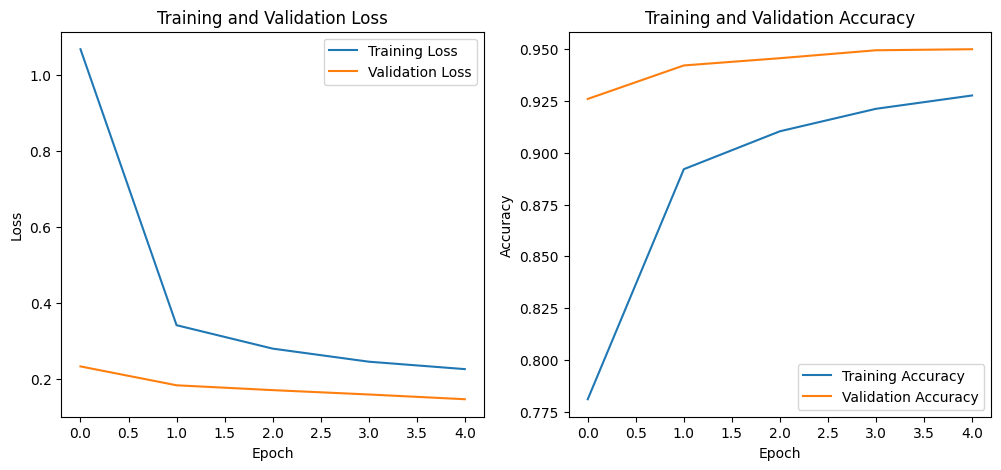

In [ ]:
loss = history.history['loss']
loss_val = history.history['val_loss']
accuracy = history.history['accuracy']
accuracy_val = history.history['val_accuracy']

plt.figure(figsize = (12, 5))
plt.subplot(1, 2, 1)
plt.plot(loss, label = 'Training Loss')
plt.plot(loss_val, label = 'Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(accuracy, label = 'Training Accuracy')
plt.plot(accuracy_val, label = 'Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(x_test_vgg, y_test)
print("Test Accuracy Before fine-tuning:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9492 - loss: 0.1562
Test Accuracy Before fine-tuning: 0.9491999745368958


**Fine Tuning**

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-4]:
    layer.trainable = False

In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history_finetune = model.fit(x_train_vgg, y_train, epochs=3, batch_size=128, validation_split=0.1)

Epoch 1/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 20s 37ms/step - accuracy: 0.9573 - loss: 0.1364 - val_accuracy: 0.9777 - val_loss: 0.0756
Epoch 2/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 27ms/step - accuracy: 0.9732 - loss: 0.0872 - val_accuracy: 0.9855 - val_loss: 0.0494
Epoch 3/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.9812 - loss: 0.0627 - val_accuracy: 0.9855 - val_loss: 0.0499


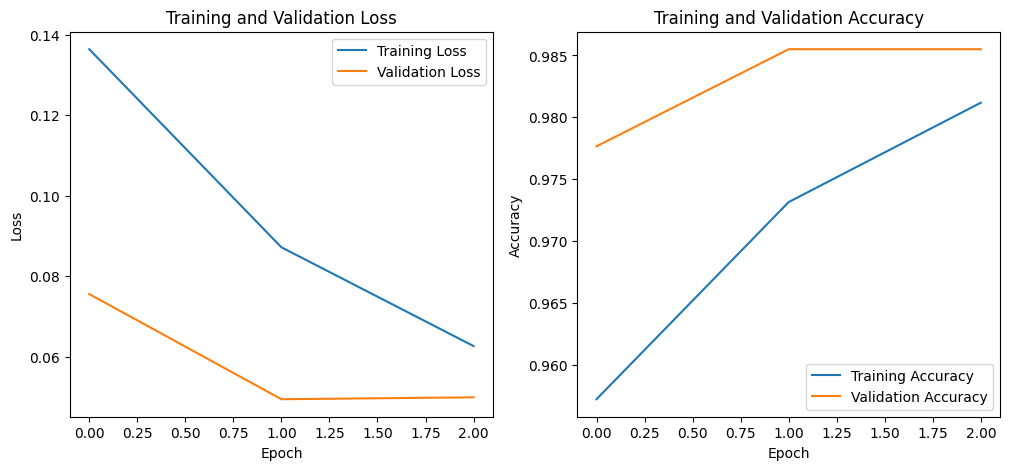

In [ ]:
loss = history_finetune.history['loss']
loss_val = history_finetune.history['val_loss']
accuracy = history_finetune.history['accuracy']
accuracy_val = history_finetune.history['val_accuracy']

plt.figure(figsize = (12, 5))
plt.subplot(1, 2, 1)
plt.plot(loss, label = 'Training Loss')
plt.plot(loss_val, label = 'Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(accuracy, label = 'Training Accuracy')
plt.plot(accuracy_val, label = 'Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(x_test_vgg, y_test)
print("Test Accuracy after fine-tuning:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9833 - loss: 0.0551
Test Accuracy after fine-tuning: 0.983299970626831


## **VGG19**

In [ ]:
print(x_train.shape, x_test.shape)

(60000, 28, 28) (10000, 28, 28)


In [ ]:
def prepare(images):
    images = tf.expand_dims(images, -1)
    images = tf.image.grayscale_to_rgb(images)
    images = tf.image.resize(images, (32, 32))
    images = vgg19.preprocess_input(images)
    return images

x_train_vgg = prepare(x_train)
x_test_vgg = prepare(x_test)

print(x_train_vgg.shape, x_test_vgg.shape)

(60000, 32, 32, 3) (10000, 32, 32, 3)


In [ ]:
base_model = VGG19(weights="imagenet", include_top=False, input_shape=(32, 32, 3))
base_model.trainable = False

base_model.summary()

Model: "vgg19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 8, 8, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 8, 8, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 4, 4, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 2, 2, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 1, 1, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,024,384 (76.39 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 20,024,384 (76.39 MB)

In [ ]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax"),
])

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg19 (Functional)              │ (None, 1, 1, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,091,338 (76.64 MB)

 Trainable params: 66,954 (261.54 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

In [ ]:
history = model.fit(x_train_vgg, y_train, epochs=5, batch_size=128, validation_split=0.1)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 24s 43ms/step - accuracy: 0.7648 - loss: 1.3428 - val_accuracy: 0.9197 - val_loss: 0.2614
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 31s 31ms/step - accuracy: 0.8845 - loss: 0.3565 - val_accuracy: 0.9367 - val_loss: 0.2005
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 14s 34ms/step - accuracy: 0.9094 - loss: 0.2814 - val_accuracy: 0.9440 - val_loss: 0.1728
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 0.9208 - loss: 0.2421 - val_accuracy: 0.9465 - val_loss: 0.1655
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 13s 32ms/step - accuracy: 0.9276 - loss: 0.2225 - val_accuracy: 0.9485 - val_loss: 0.1626


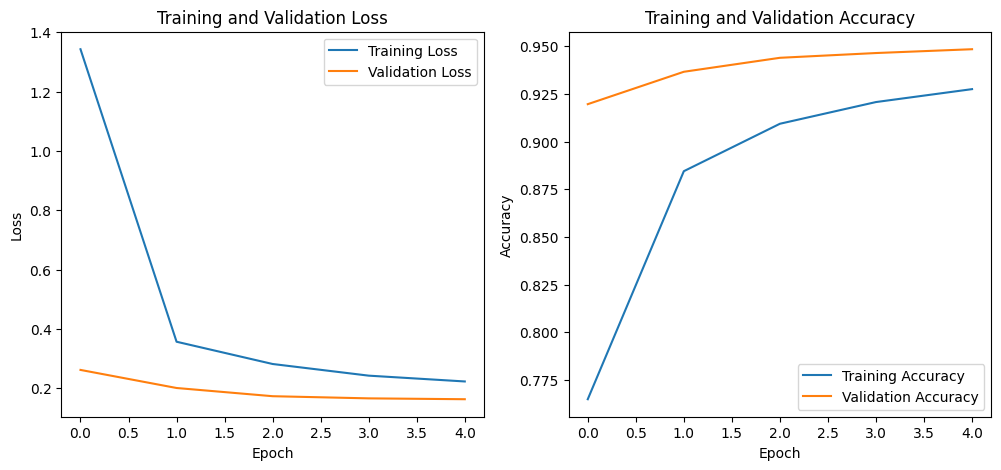

In [ ]:
loss = history.history['loss']
loss_val = history.history['val_loss']
accuracy = history.history['accuracy']
accuracy_val = history.history['val_accuracy']

plt.figure(figsize = (12, 5))
plt.subplot(1, 2, 1)
plt.plot(loss, label = 'Training Loss')
plt.plot(loss_val, label = 'Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(accuracy, label = 'Training Accuracy')
plt.plot(accuracy_val, label = 'Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(x_test_vgg, y_test)
print("Test Accuracy Before fine-tuning:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9468 - loss: 0.1716
Test Accuracy Before fine-tuning: 0.9467999935150146


**Fine Tuning**

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-4]:
    layer.trainable = False

In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history_finetune = model.fit(x_train_vgg, y_train, epochs=3, batch_size=128, validation_split=0.1)

Epoch 1/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 25s 48ms/step - accuracy: 0.9539 - loss: 0.1460 - val_accuracy: 0.9718 - val_loss: 0.0924
Epoch 2/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 15s 37ms/step - accuracy: 0.9693 - loss: 0.0965 - val_accuracy: 0.9777 - val_loss: 0.0753
Epoch 3/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 16s 39ms/step - accuracy: 0.9767 - loss: 0.0766 - val_accuracy: 0.9823 - val_loss: 0.0692


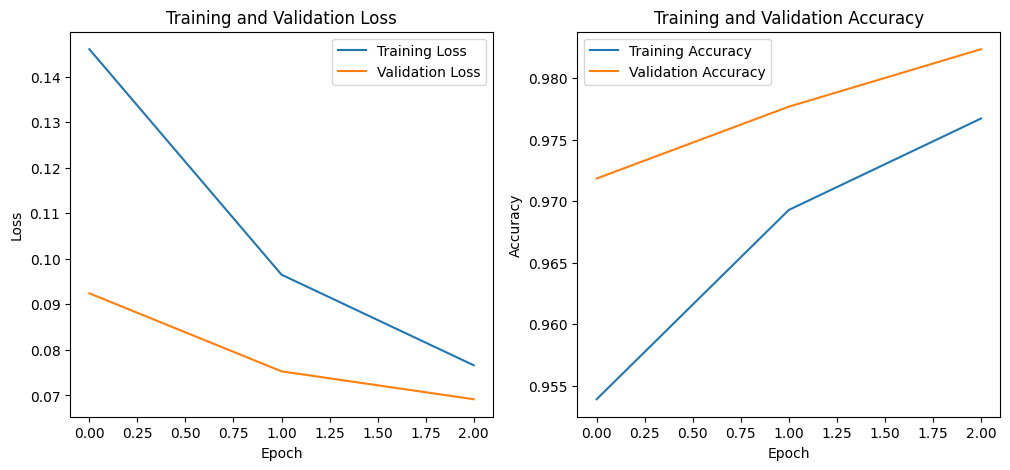

In [ ]:
loss = history_finetune.history['loss']
loss_val = history_finetune.history['val_loss']
accuracy = history_finetune.history['accuracy']
accuracy_val = history_finetune.history['val_accuracy']

plt.figure(figsize = (12, 5))
plt.subplot(1, 2, 1)
plt.plot(loss, label = 'Training Loss')
plt.plot(loss_val, label = 'Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(accuracy, label = 'Training Accuracy')
plt.plot(accuracy_val, label = 'Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(x_test_vgg, y_test)
print("Test Accuracy after fine-tuning:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9790 - loss: 0.0702
Test Accuracy after fine-tuning: 0.9789999723434448


## **LeNet50**

In [ ]:
LeNet5_Model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 220, 220, 6)    │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 110, 110, 6)    │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 106, 106, 6)    │           906 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 53, 53, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 53, 53, 120)    │           840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 337080)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │    28,314,804 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,317,856 (108.02 MB)

 Trainable params: 28,317,856 (108.02 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
preprocessing_model = models.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Reshape((28, 28, 1)),
    layers.Lambda(lambda x: tf.image.grayscale_to_rgb(x)),
    layers.Resizing(224, 224)
], name="preprocessing_stage")

In [ ]:
model = models.Sequential([
    preprocessing_model,  # Your isolated image processing steps
    LeNet5_Model,         # The core base model
], name="complete_pipeline")

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

Model: "complete_pipeline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ preprocessing_stage             │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 10)             │    28,317,856 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,317,856 (108.02 MB)

 Trainable params: 28,317,856 (108.02 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

Model: "complete_pipeline"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ preprocessing_stage             │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 10)             │    28,317,856 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,317,856 (108.02 MB)

 Trainable params: 28,317,856 (108.02 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(x_train, y_train, epochs=5, batch_size=128, validation_split=0.1)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 45s 87ms/step - accuracy: 0.9153 - loss: 0.2977 - val_accuracy: 0.9542 - val_loss: 0.1652
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 65s 63ms/step - accuracy: 0.9523 - loss: 0.1638 - val_accuracy: 0.9632 - val_loss: 0.1319
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 27s 63ms/step - accuracy: 0.9558 - loss: 0.1470 - val_accuracy: 0.9718 - val_loss: 0.1069
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 27s 63ms/step - accuracy: 0.9554 - loss: 0.1475 - val_accuracy: 0.9662 - val_loss: 0.1219
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 26s 63ms/step - accuracy: 0.9557 - loss: 0.1445 - val_accuracy: 0.9627 - val_loss: 0.1248


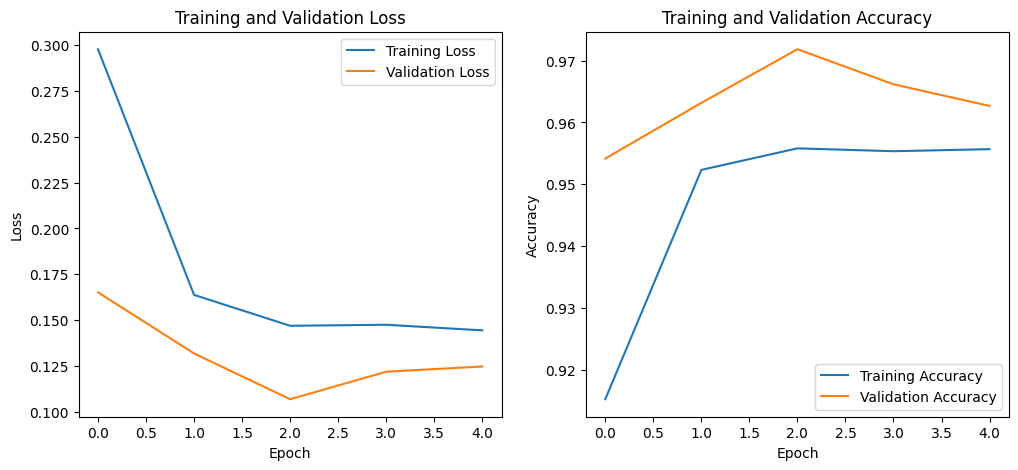

In [ ]:
loss = history.history['loss']
loss_val = history.history['val_loss']
accuracy = history.history['accuracy']
accuracy_val = history.history['val_accuracy']

plt.figure(figsize = (12, 5))
plt.subplot(1, 2, 1)
plt.plot(loss, label = 'Training Loss')
plt.plot(loss_val, label = 'Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(accuracy, label = 'Training Accuracy')
plt.plot(accuracy_val, label = 'Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy after fine-tuning:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9572 - loss: 0.1348
Test Accuracy after fine-tuning: 0.9571999907493591


## **ResNet50**

In [ ]:
print(x_train.shape, x_test.shape)

(60000, 28, 28) (10000, 28, 28)


In [ ]:
def prepare(images):
    images = tf.expand_dims(images, -1)         # (N,28,28) -> (N,28,28,1)
    images = tf.image.grayscale_to_rgb(images)  # -> (N,28,28,3)
    images = tf.image.resize(images, (32, 32))  # -> (N,32,32,3)
    images = preprocess_input(images)
    return images

x_train_res = prepare(x_train)
x_test_res = prepare(x_test)

print(x_train_res.shape, x_test_res.shape)

(60000, 32, 32, 3) (10000, 32, 32, 3)


### **Train Manual Implementation**

In [ ]:
ResNet50_model.summary()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_15      │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_81 (Conv2D)  │ (None, 32, 32,    │        896 │ input_layer_15[0… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_82 (Conv2D)  │ (None, 32, 32,    │      9,248 │ conv2d_81[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_83 (Conv2D)  │ (None, 32, 32,    │      9,248 │ conv2d_82[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_6 (Add)         │ (None, 32, 32,    │          0 │ conv2d_83[0][0],  │
│                     │ 32)               │            │ conv2d_81[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_6        │ (None, 32, 32,    │          0 │ add_6[0][0]       │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_26    │ (None, 16, 16,    │          0 │ activation_6[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_84 (Conv2D)  │ (None, 16, 16,    │     18,496 │ max_pooling2d_26… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_85 (Conv2D)  │ (None, 16, 16,    │     36,928 │ conv2d_84[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_86 (Conv2D)  │ (None, 16, 16,    │      2,112 │ max_pooling2d_26… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 16, 16,    │          0 │ conv2d_85[0][0],  │
│                     │ 64)               │            │ conv2d_86[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_7        │ (None, 16, 16,    │          0 │ add_7[0][0]       │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_27    │ (None, 8, 8, 64)  │          0 │ activation_7[0][… │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_8 (Flatten) │ (None, 4096)      │          0 │ max_pooling2d_27… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_27 (Dense)    │ (None, 128)       │    524,416 │ flatten_8[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_28 (Dense)    │ (None, 10)        │      1,290 │ dense_27[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 602,634 (2.30 MB)

 Trainable params: 602,634 (2.30 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
ResNet50_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [ ]:
history = ResNet50_model.fit(x_train_res, y_train, epochs=5, batch_size=128, validation_split=0.1)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.8938 - loss: 1.7029 - val_accuracy: 0.9742 - val_loss: 0.0888
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.9740 - loss: 0.0845 - val_accuracy: 0.9792 - val_loss: 0.0803
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9828 - loss: 0.0552 - val_accuracy: 0.9808 - val_loss: 0.0665
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9862 - loss: 0.0440 - val_accuracy: 0.9847 - val_loss: 0.0612
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9886 - loss: 0.0368 - val_accuracy: 0.9825 - val_loss: 0.0617


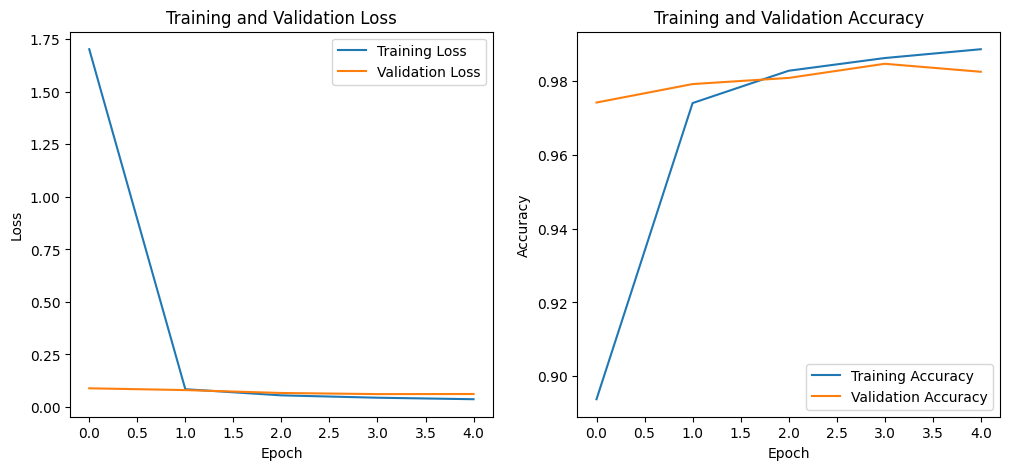

In [ ]:
loss = history.history['loss']
loss_val = history.history['val_loss']
accuracy = history.history['accuracy']
accuracy_val = history.history['val_accuracy']

plt.figure(figsize = (12, 5))
plt.subplot(1, 2, 1)
plt.plot(loss, label = 'Training Loss')
plt.plot(loss_val, label = 'Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(accuracy, label = 'Training Accuracy')
plt.plot(accuracy_val, label = 'Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.show()

In [ ]:
test_loss, test_acc = ResNet50_model.evaluate(x_test_res, y_test)
print("Test Accuracy of Maual Implementatoin:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9818 - loss: 0.0582
Test Accuracy of Maual Implementatoin: 0.9818000197410583


### **Train Pretrained Model**

In [ ]:
base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(32, 32, 3))
base_model.trainable = False

base_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_12      │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 38, 38, 3) │          0 │ input_layer_12[0… │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 16, 16,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 16, 16,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 16, 16,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 18, 18,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 8, 8, 64)  │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 8, 8, 64)  │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_1_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 8, 8, 64)  │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 8, 8, 64)  │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 8, 8, 64)  │          0 │ conv2_block1_2_b… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 8, 8, 256) │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 8, 8, 256) │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 8, 8, 256) │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 8, 8, 256) │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(10, activation="softmax"),
])

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 1, 1, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,851,274 (90.99 MB)

 Trainable params: 263,562 (1.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [ ]:
history = model.fit(x_train_res, y_train, epochs=5, batch_size=128, validation_split=0.1)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 30s 43ms/step - accuracy: 0.8520 - loss: 0.4648 - val_accuracy: 0.9347 - val_loss: 0.2027
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9199 - loss: 0.2436 - val_accuracy: 0.9450 - val_loss: 0.1659
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9324 - loss: 0.2048 - val_accuracy: 0.9567 - val_loss: 0.1368
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 0.9402 - loss: 0.1814 - val_accuracy: 0.9537 - val_loss: 0.1463
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - accuracy: 0.9445 - loss: 0.1669 - val_accuracy: 0.9575 - val_loss: 0.1322


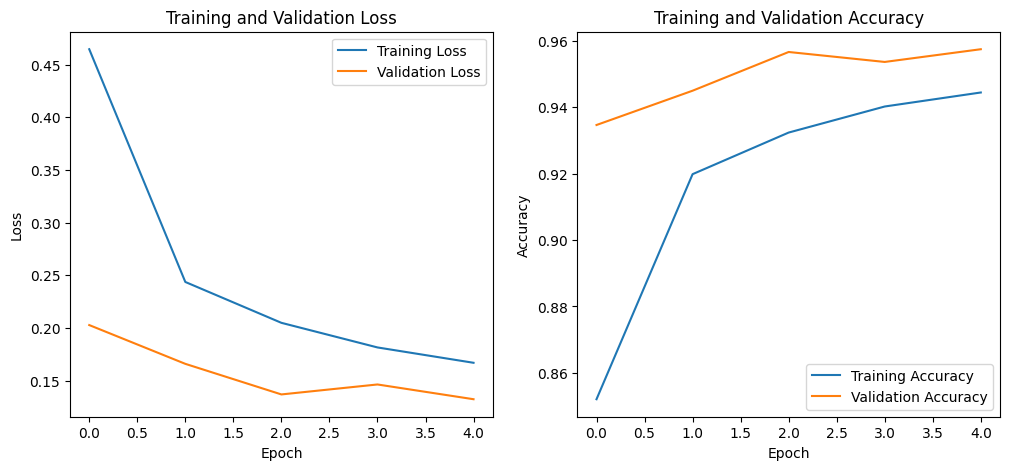

In [ ]:
loss = history.history['loss']
loss_val = history.history['val_loss']
accuracy = history.history['accuracy']
accuracy_val = history.history['val_accuracy']

plt.figure(figsize = (12, 5))
plt.subplot(1, 2, 1)
plt.plot(loss, label = 'Training Loss')
plt.plot(loss_val, label = 'Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(accuracy, label = 'Training Accuracy')
plt.plot(accuracy_val, label = 'Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(x_test_res, y_test)
print("Test Accuracy Before fine-tuning:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.9505 - loss: 0.1512
Test Accuracy Before fine-tuning: 0.9505000114440918


**Fine Tuning**

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-4]:
    layer.trainable = False

In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history_finetune = model.fit(x_train_res, y_train, epochs=3, batch_size=128, validation_split=0.1)

Epoch 1/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 34s 40ms/step - accuracy: 0.9383 - loss: 0.1972 - val_accuracy: 0.9543 - val_loss: 0.1446
Epoch 2/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9500 - loss: 0.1483 - val_accuracy: 0.9603 - val_loss: 0.1345
Epoch 3/3
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9551 - loss: 0.1331 - val_accuracy: 0.9610 - val_loss: 0.1285


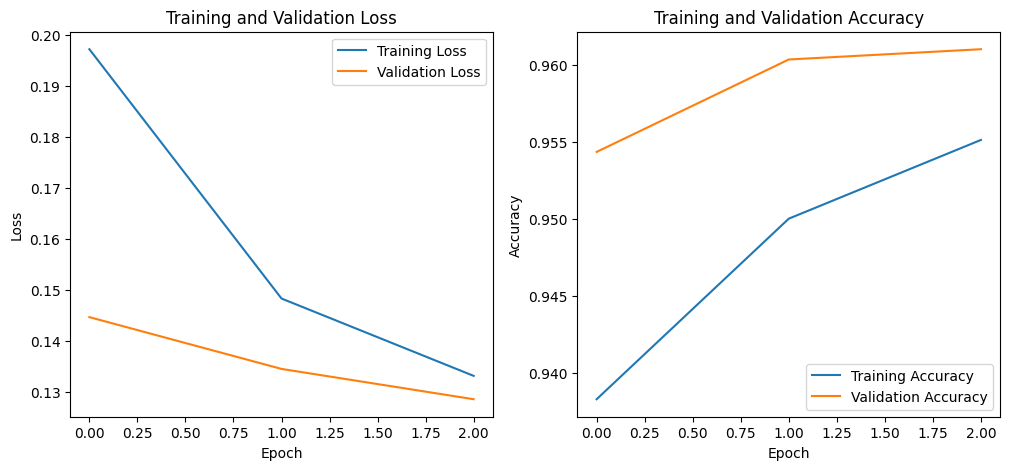

In [ ]:
loss = history_finetune.history['loss']
loss_val = history_finetune.history['val_loss']
accuracy = history_finetune.history['accuracy']
accuracy_val = history_finetune.history['val_accuracy']

plt.figure(figsize = (12, 5))
plt.subplot(1, 2, 1)
plt.plot(loss, label = 'Training Loss')
plt.plot(loss_val, label = 'Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(accuracy, label = 'Training Accuracy')
plt.plot(accuracy_val, label = 'Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(x_test_res, y_test)
print("Test Accuracy after fine-tuning:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9567 - loss: 0.1511
Test Accuracy after fine-tuning: 0.9567000269889832


## **AlexNet**

In [ ]:
print(x_train.shape, x_test.shape)

(60000, 28, 28) (10000, 28, 28)


In [ ]:
x_train_alex = x_train
x_test_alex = x_test

### **Train Manual Implementation**

In [ ]:
AlexNet_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_46 (Conv2D)              │ (None, 28, 28, 96)     │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 14, 14, 96)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 14, 14, 256)    │       221,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 7, 7, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_48 (Conv2D)              │ (None, 7, 7, 384)      │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_49 (Conv2D)              │ (None, 7, 7, 384)      │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_50 (Conv2D)              │ (None, 7, 7, 256)      │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 4096)           │     9,441,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 10)             │        40,970 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,583,562 (112.85 MB)

 Trainable params: 29,583,562 (112.85 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
AlexNet_model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [ ]:
history = AlexNet_model.fit(x_train_alex, y_train, epochs=5, batch_size=128, validation_split=0.1)

Epoch 1/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 42s 71ms/step - accuracy: 0.8957 - loss: 0.5287 - val_accuracy: 0.9830 - val_loss: 0.0594
Epoch 2/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 18s 43ms/step - accuracy: 0.9789 - loss: 0.0705 - val_accuracy: 0.9828 - val_loss: 0.0634
Epoch 3/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 18s 43ms/step - accuracy: 0.9842 - loss: 0.0546 - val_accuracy: 0.9848 - val_loss: 0.0525
Epoch 4/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 18s 43ms/step - accuracy: 0.9867 - loss: 0.0457 - val_accuracy: 0.9883 - val_loss: 0.0485
Epoch 5/5
422/422 ━━━━━━━━━━━━━━━━━━━━ 18s 43ms/step - accuracy: 0.9881 - loss: 0.0423 - val_accuracy: 0.9860 - val_loss: 0.0515


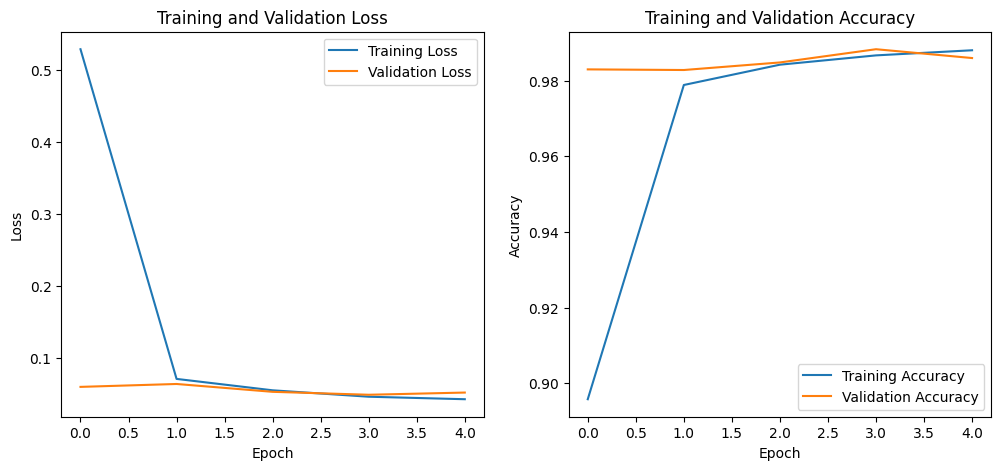

In [ ]:
loss = history.history['loss']
loss_val = history.history['val_loss']
accuracy = history.history['accuracy']
accuracy_val = history.history['val_accuracy']

plt.figure(figsize = (12, 5))
plt.subplot(1, 2, 1)
plt.plot(loss, label = 'Training Loss')
plt.plot(loss_val, label = 'Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(accuracy, label = 'Training Accuracy')
plt.plot(accuracy_val, label = 'Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.show()

In [ ]:
test_loss, test_acc = AlexNet_model.evaluate(x_test_alex, y_test)
print("Test Accuracy of Maual Implementatoin:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9856 - loss: 0.0536
Test Accuracy of Maual Implementatoin: 0.9855999946594238
